# T45 — Global porphyry-Cu paleo-prospectivity through subduction kinematics

**A pyGMT modernisation of the Butterworth et al. (2021) spatio-temporal subduction-kinematics methodology applied to a global porphyry-Cu compilation. Reconstructs each deposit to its mineralisation age under Zahirovic 2022, samples reconstructed convergence rate / subduction-zone proximity / segment age at the paleo-position, and builds the per-deposit feature stack used by reconstruction-driven ML prospectivity classifiers.**

## What this notebook produces

T44 and T40 each focus on a regional porphyry province (SW Pacific arc; Andean margin). T45 zooms out to the global compilation and asks the methodological question: when porphyry deposits form, what subduction kinematics is contemporaneously active above them? The notebook reconstructs 120 deposits spanning ~400 Ma to present, samples a kinematic feature stack at each paleo-position, and renders (i) a global paleo-Earth map at three representative ages showing the deposit distribution under the contemporaneous subduction geometry, (ii) histograms of per-deposit paleo-distance to nearest trench and reconstructed convergence rate at the closest trench segment, and (iii) the bivariate scatter of distance versus convergence rate that anchors the Butterworth et al. (2021) prospectivity classifier.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.

## Learning objectives

- Reconstruct a global ore-deposit compilation under a published plate model at each deposit's individual mineralisation age.
- Sample reconstructed subduction-zone segments for kinematic properties (convergence rate, segment age) at the closest segment to each deposit using `pygplates.tessellate_subduction_zones`.
- Build a per-deposit feature stack ready for a reconstruction-driven prospectivity classifier.
- Recognise the spatio-temporal envelope ("porphyry-generating distance × convergence rate" window) that the global compilation occupies.

## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Data**: `data/porphyry_cu_global/global_porphyry_cu.csv` — bundled tutorial compilation, 120 deposits.
- **Python**: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`, `matplotlib`.
- **Runtime**: ~2 minutes (per-deposit reconstruction + per-deposit kinematic sampling).

## Data availability

This notebook reads the bundled global porphyry-Cu compilation at `data/porphyry_cu_global/global_porphyry_cu.csv`. The top 30 entries are canonical supergiants/giants drawn from the published literature; the remaining ~90 are synthetic mid-tier deposits that fill out the spatio-temporal field for tutorial purposes. For production-scale work, replace with one of:

- **Mutschler et al. (1999)**: USGS Open-File Report 99-556 — `https://pubs.usgs.gov/of/1999/of99-556/`
- **Singer et al. (2008)**: USGS DDS-75 porphyry-Cu compilation — `https://pubs.usgs.gov/dds/2005/75/`
- **EarthByte porphyry_copper_spatiotemporal_exploration**: the Butterworth et al. (2021) study repository at `https://github.com/EarthByte/porphyry_copper_spatiotemporal_exploration`.

In [8]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Library versions (printed for reproducibility)
try:
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")

# matplotlib equivalent of pyGMT's 'hawaii' (cmcrameri).
# Falls back to plasma_r if cmcrameri isn't installed in
# the conda env, so the matplotlib panels still render.
try:
    import cmcrameri.cm as _cmc
    AGE_CMAP_MPL = _cmc.hawaii_r
except ImportError:
    AGE_CMAP_MPL = "plasma_r"


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

In [9]:
# === USER CONFIGURATION =====================================================
DEPOSITS_CSV   = "data/porphyry_cu_global/global_porphyry_cu.csv"
MODEL_NAME     = "Zahirovic2022"
SNAPSHOT_TIMES = (10.0, 50.0, 150.0)   # Ma — three representative paleo-maps
ANCHOR_PLATE_ID = 0
TRENCH_SAMPLE_SPACING_DEG = 2.0        # spacing for trench sampling
NEAR_TRENCH_KM = 1000.0                # distance cutoff for "near-trench"
# ============================================================================


## 1. Load the global compilation

In [10]:
# Cell 2 — load
dep = pd.read_csv(DEPOSITS_CSV, comment="#")
dep.columns = [c.strip() for c in dep.columns]
print(f"  loaded {len(dep)} deposits | ages {dep.age_ma.min():.0f}–{dep.age_ma.max():.0f} Ma | {dep.commodity.nunique()} commodity classes")
dep.head()


  loaded 120 deposits | ages 0–395 Ma | 5 commodity classes


,name,lon,lat,age_ma,commodity,tier
0,Chuquicamata,-68.91,-22.30,33.0,Cu,supergiant
1,Escondida,-69.06,-24.27,38.0,Cu,supergiant
2,El Teniente,-70.36,-34.08,4.7,Cu,supergiant
3,Andina-Río Blanco,-70.27,-33.13,5.2,Cu,giant
4,Collahuasi,-68.74,-20.99,32.0,Cu,giant


## 2. Reconstruct each deposit to its mineralisation age

In [11]:
# Cell 3 — per-deposit paleo-positions
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

paleo_lons, paleo_lats = [], []
for _, row in dep.iterrows():
    pt = gplately.Points(recon, [row["lon"]], [row["lat"]])
    rlon, rlat = pt.reconstruct(float(row["age_ma"]), return_array=True)
    paleo_lons.append(float(rlon[0])); paleo_lats.append(float(rlat[0]))
dep["paleo_lon"] = paleo_lons
dep["paleo_lat"] = paleo_lats
print(f"  reconstructed {len(dep)} deposits")


  reconstructed 120 deposits


## 3. Per-deposit kinematic sampling at the closest contemporaneous trench

In [12]:
# Cell 4 — sample trench segments at each deposit's paleo-position
def sample_kinematics(age_ma, plon, plat):
    """At reconstruction time age_ma, find the closest trench segment to
    (plon, plat) and return (distance_km, convergence_rate_mm_yr,
    closest_trench_lon, closest_trench_lat)."""
    trench_data = recon.tessellate_subduction_zones(
        float(age_ma), tessellation_threshold_radians=np.deg2rad(TRENCH_SAMPLE_SPACING_DEG))
    if trench_data is None or len(trench_data) == 0:
        return (np.nan, np.nan, np.nan, np.nan)
    # tessellate_subduction_zones returns: lon, lat, conv_velocity, conv_obliquity,
    #   trench_velocity, trench_obliquity, segment_length, trench_normal_azimuth,
    #   subducting_plate_id, overriding_plate_id
    t_lons    = trench_data[:, 0]
    t_lats    = trench_data[:, 1]
    conv_rate = trench_data[:, 2]   # mm/yr
    # Spherical distance from (plon, plat) to every trench sample
    p = pygplates.PointOnSphere(plat, plon)
    dists = np.array([
        pygplates.GeometryOnSphere.distance(p, pygplates.PointOnSphere(la, lo)) * 6371.0
        for lo, la in zip(t_lons, t_lats)])
    idx = int(np.argmin(dists))
    return float(dists[idx]), float(conv_rate[idx]), float(t_lons[idx]), float(t_lats[idx])

print("  sampling kinematics — this is the slow cell (~30s for 120 deposits)...")
results = [sample_kinematics(r.age_ma, r.paleo_lon, r.paleo_lat) for r in dep.itertuples()]
dep[["trench_dist_km","conv_rate_mmyr","trench_lon","trench_lat"]] = results
print(f"  median trench distance: {dep.trench_dist_km.median():.0f} km")
print(f"  median conv. rate at closest trench: {dep.conv_rate_mmyr.median():.0f} mm/yr")
print(f"  % within {NEAR_TRENCH_KM:.0f} km of a trench: {100*(dep.trench_dist_km < NEAR_TRENCH_KM).mean():.0f} %")


  sampling kinematics — this is the slow cell (~30s for 120 deposits)...
  median trench distance: 688 km
  median conv. rate at closest trench: 4 mm/yr
  % within 1000 km of a trench: 62 %


## 4. Three paleo-Earth maps with deposits + contemporaneous subduction

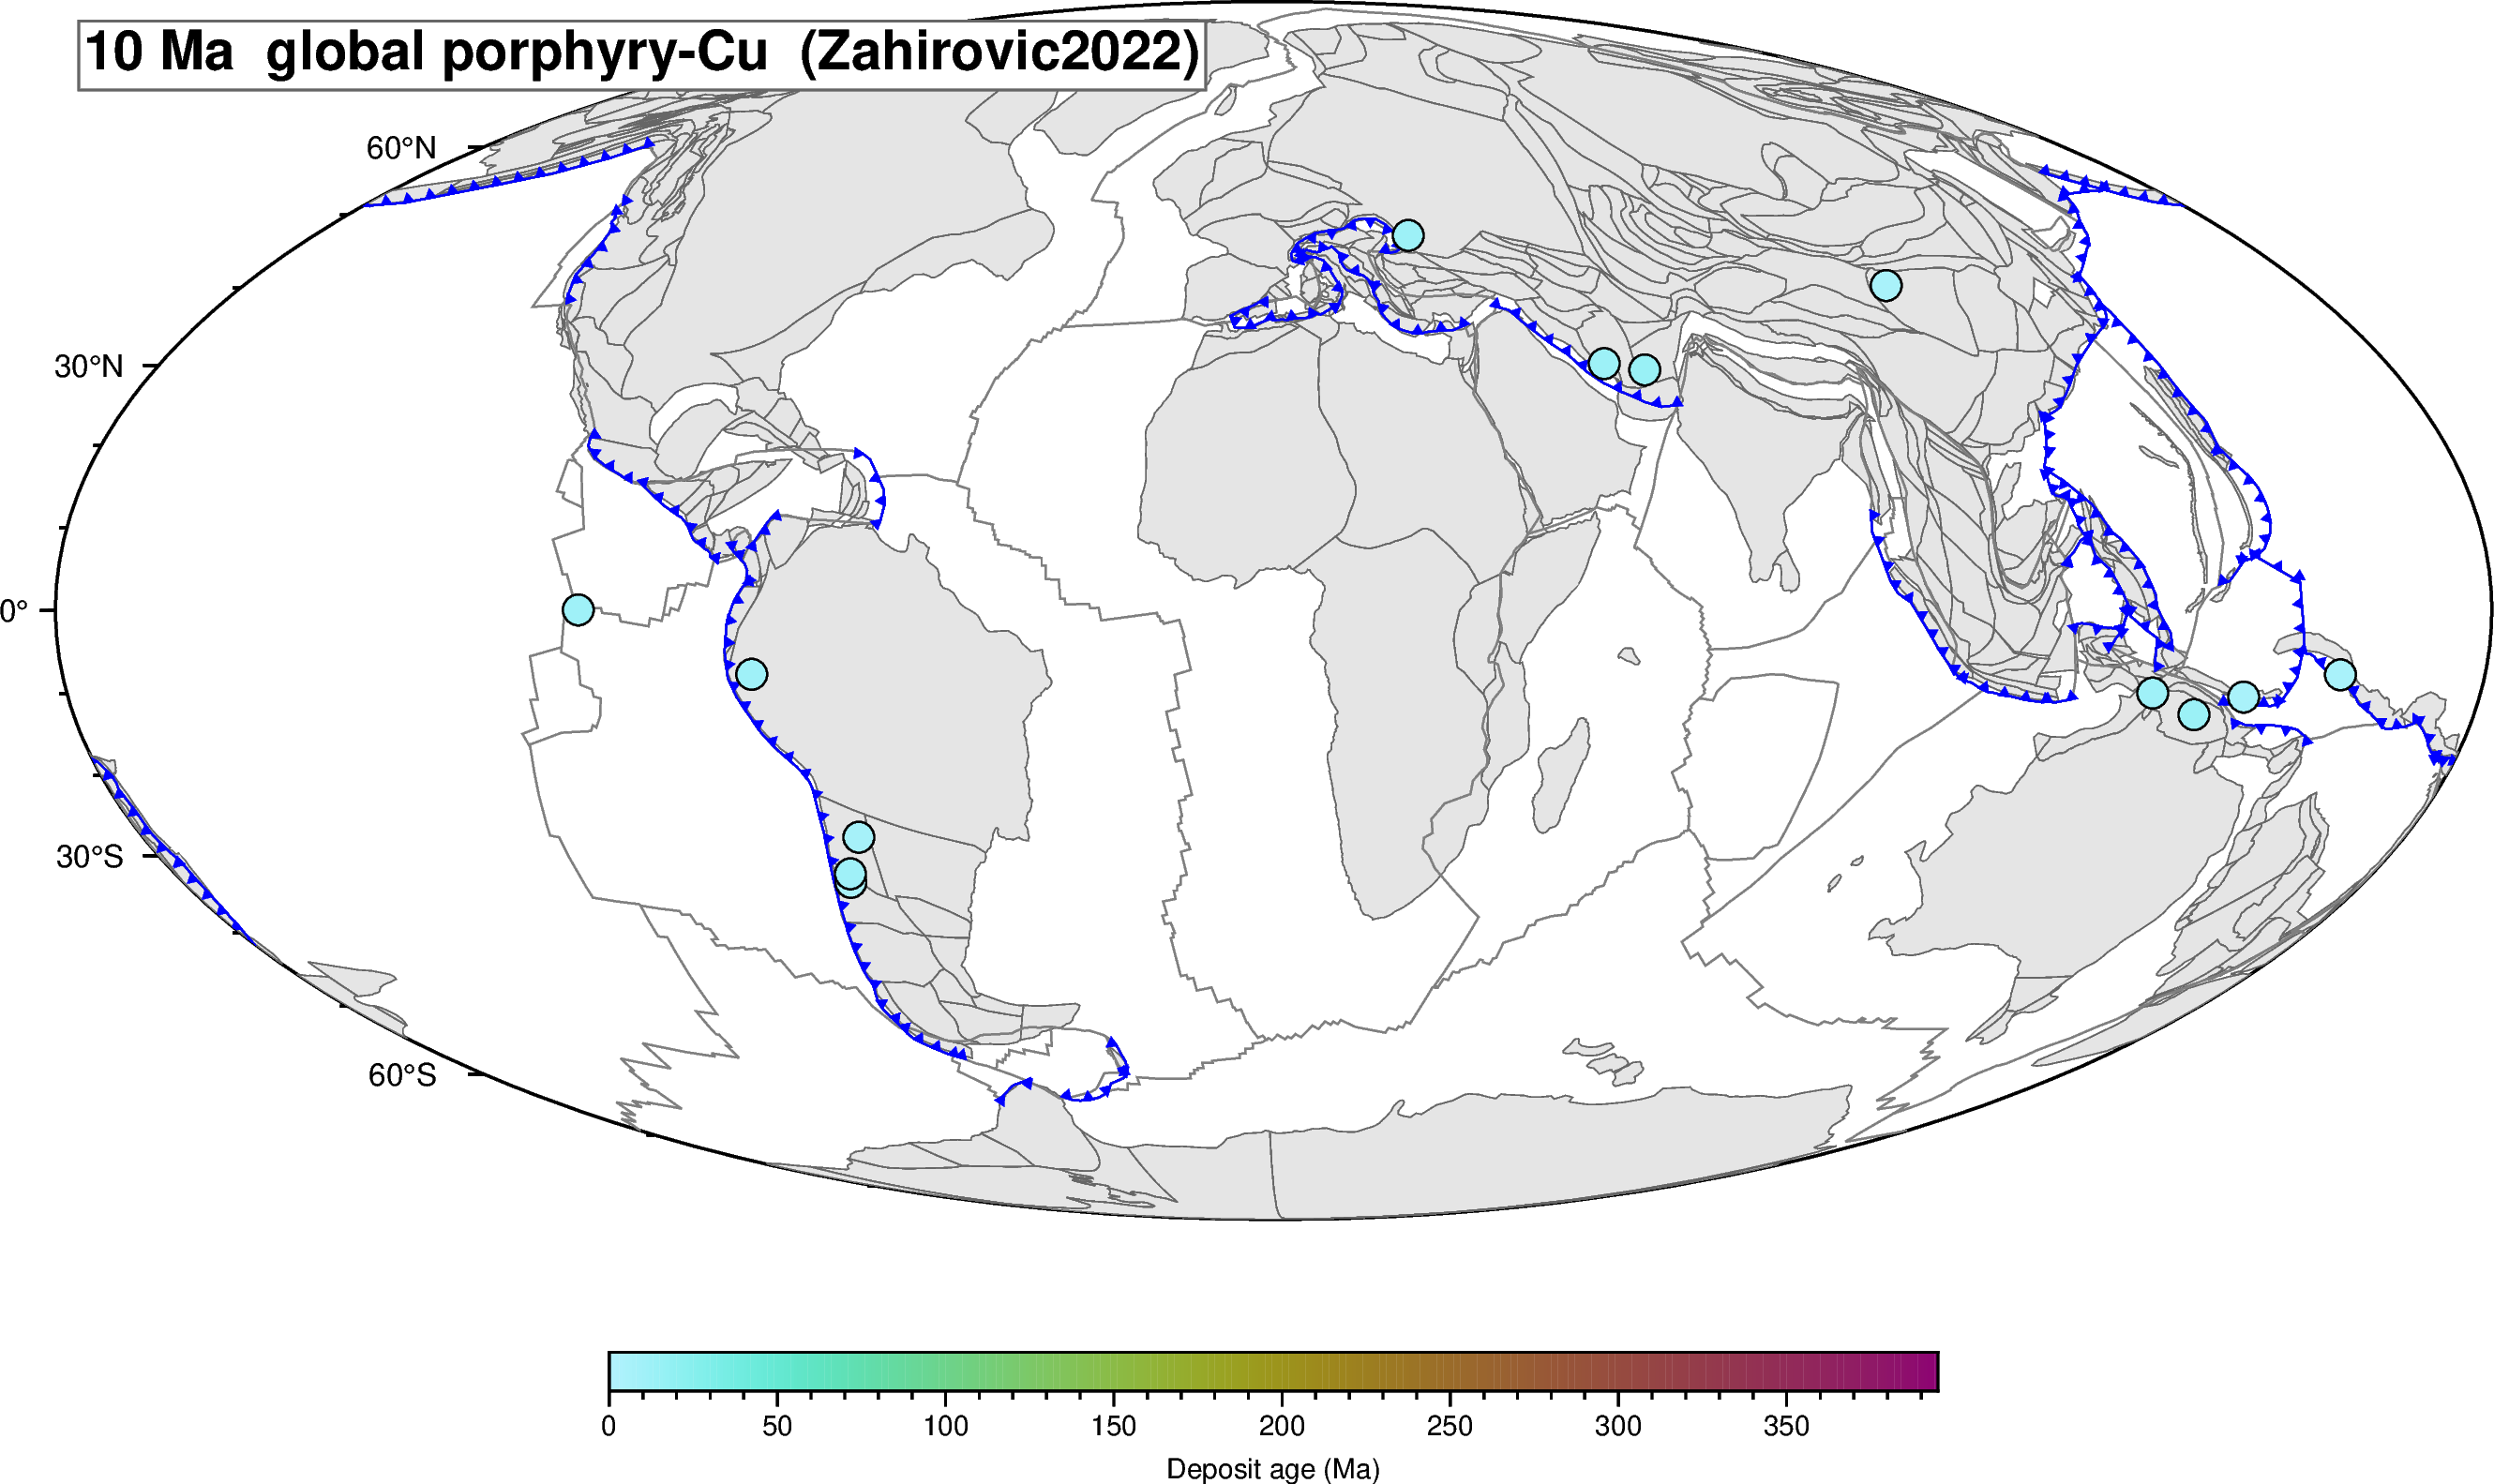

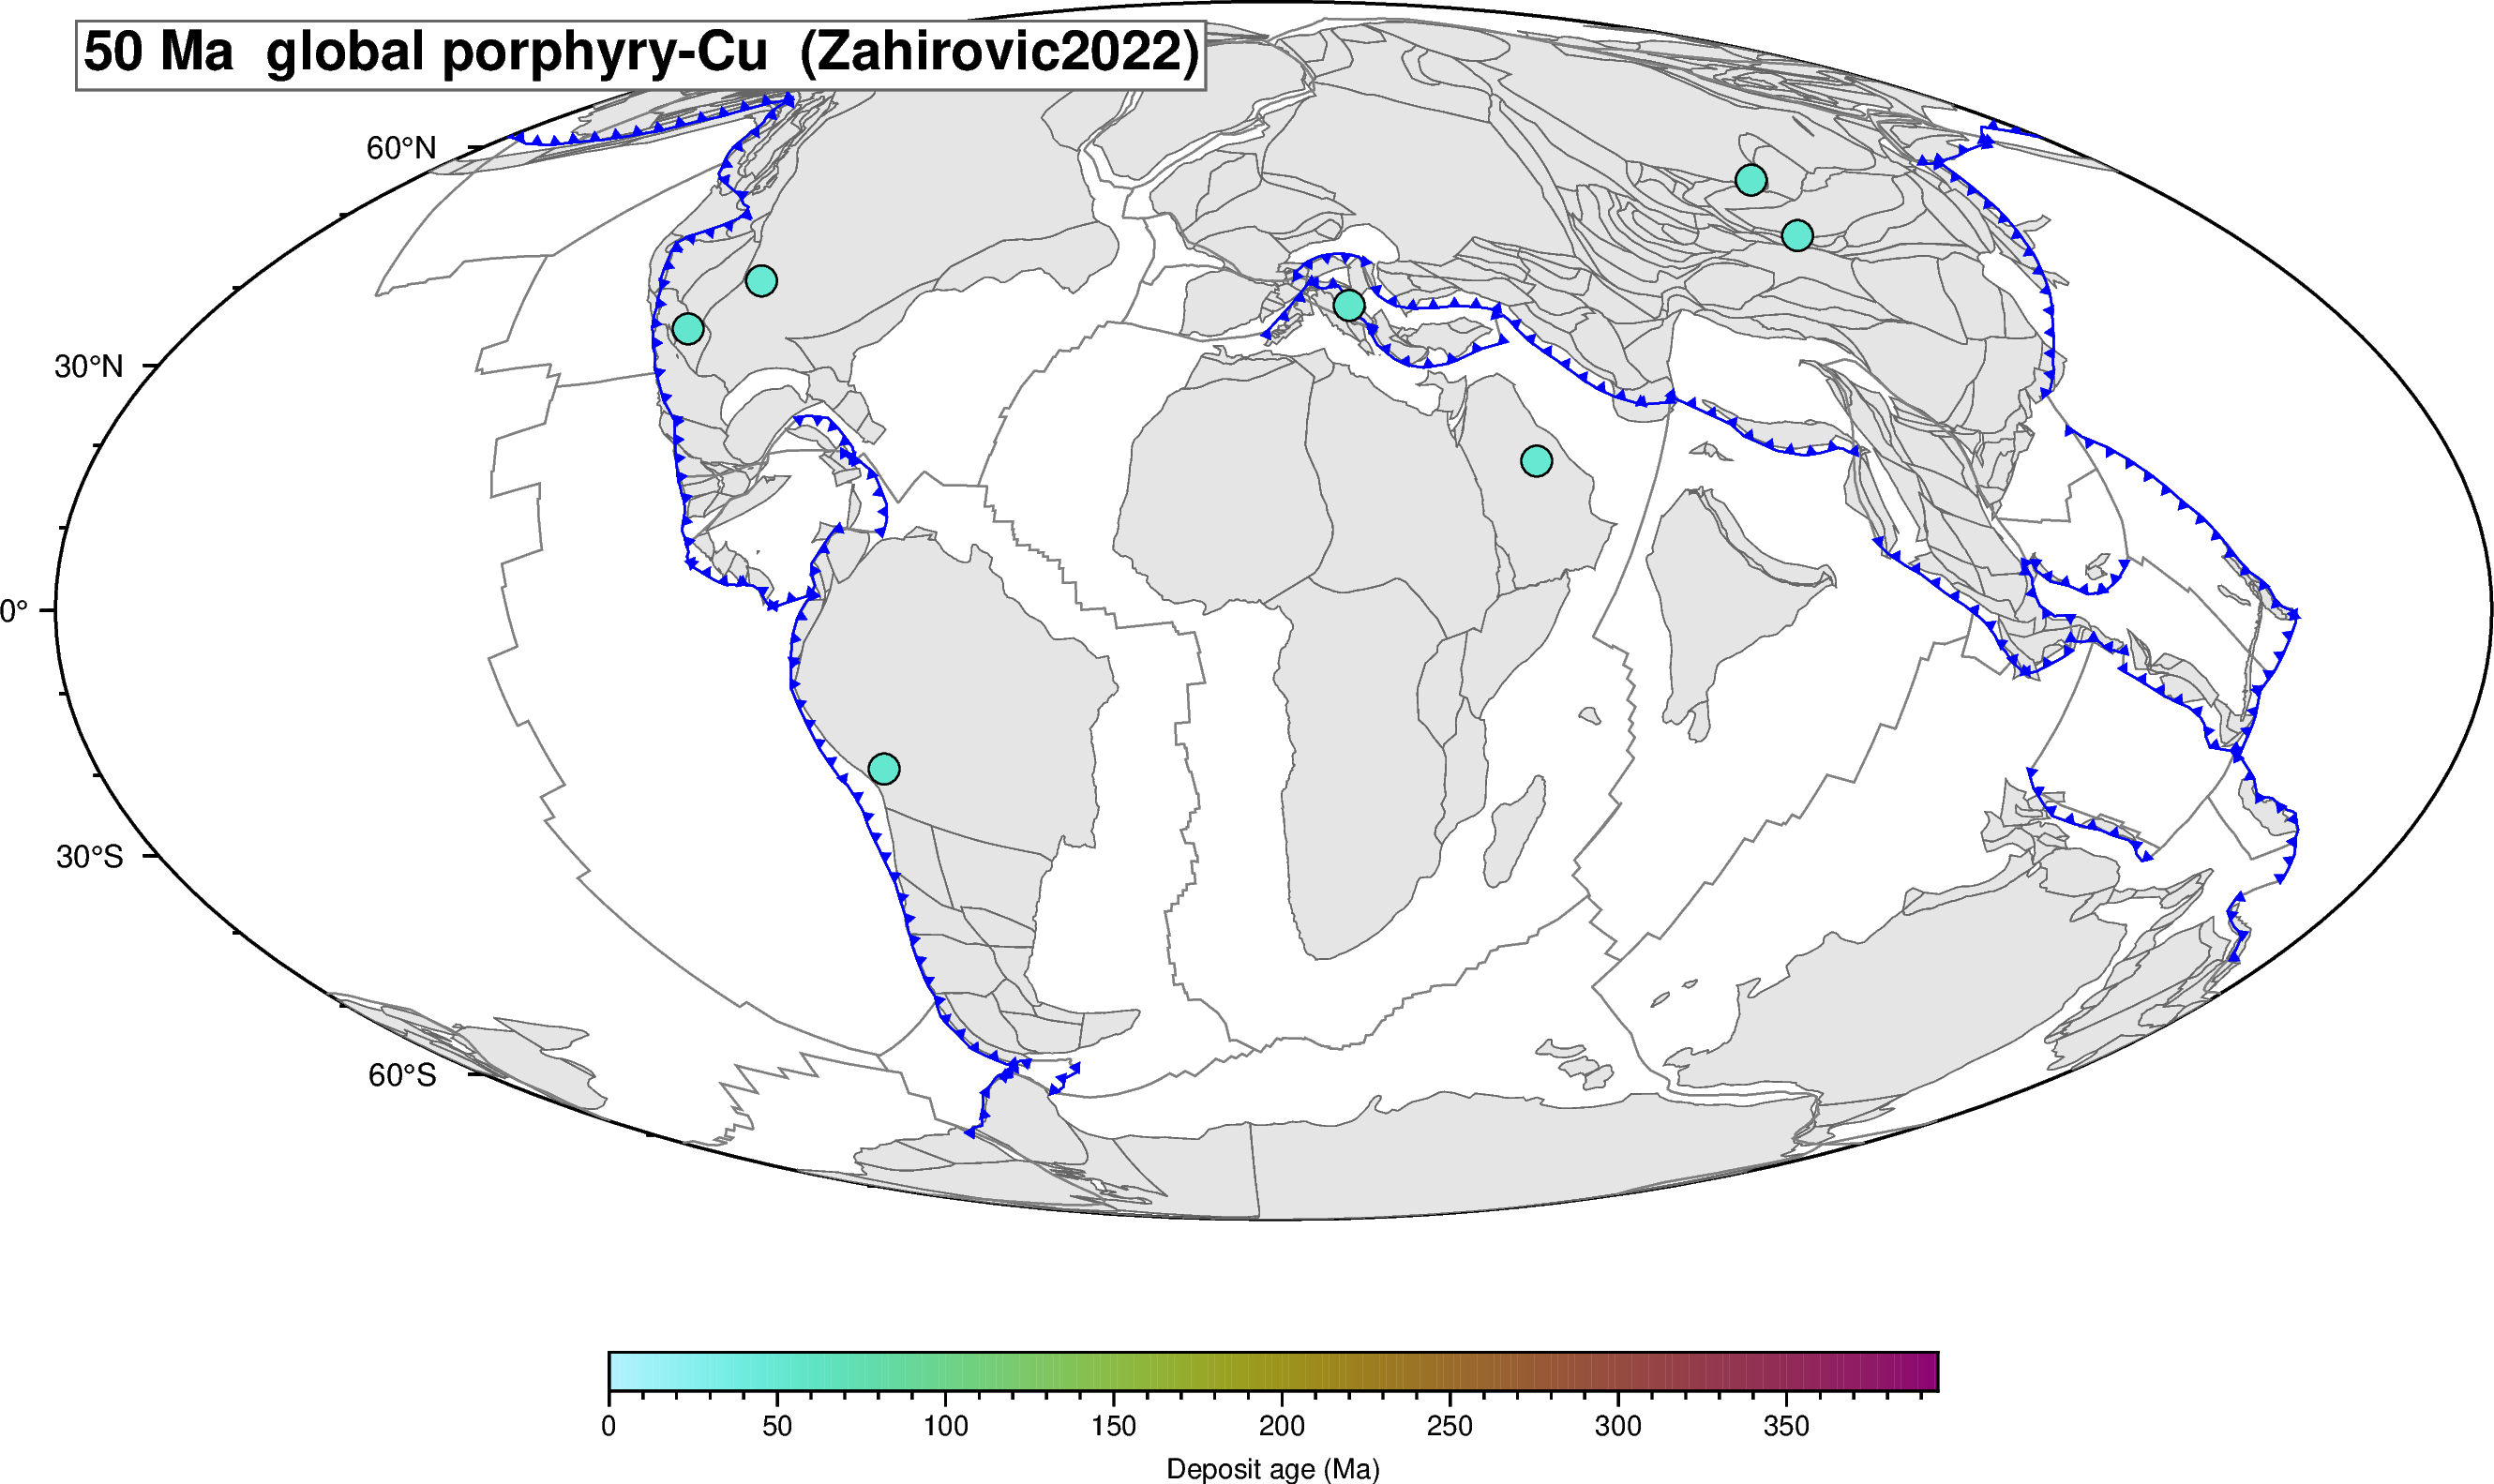

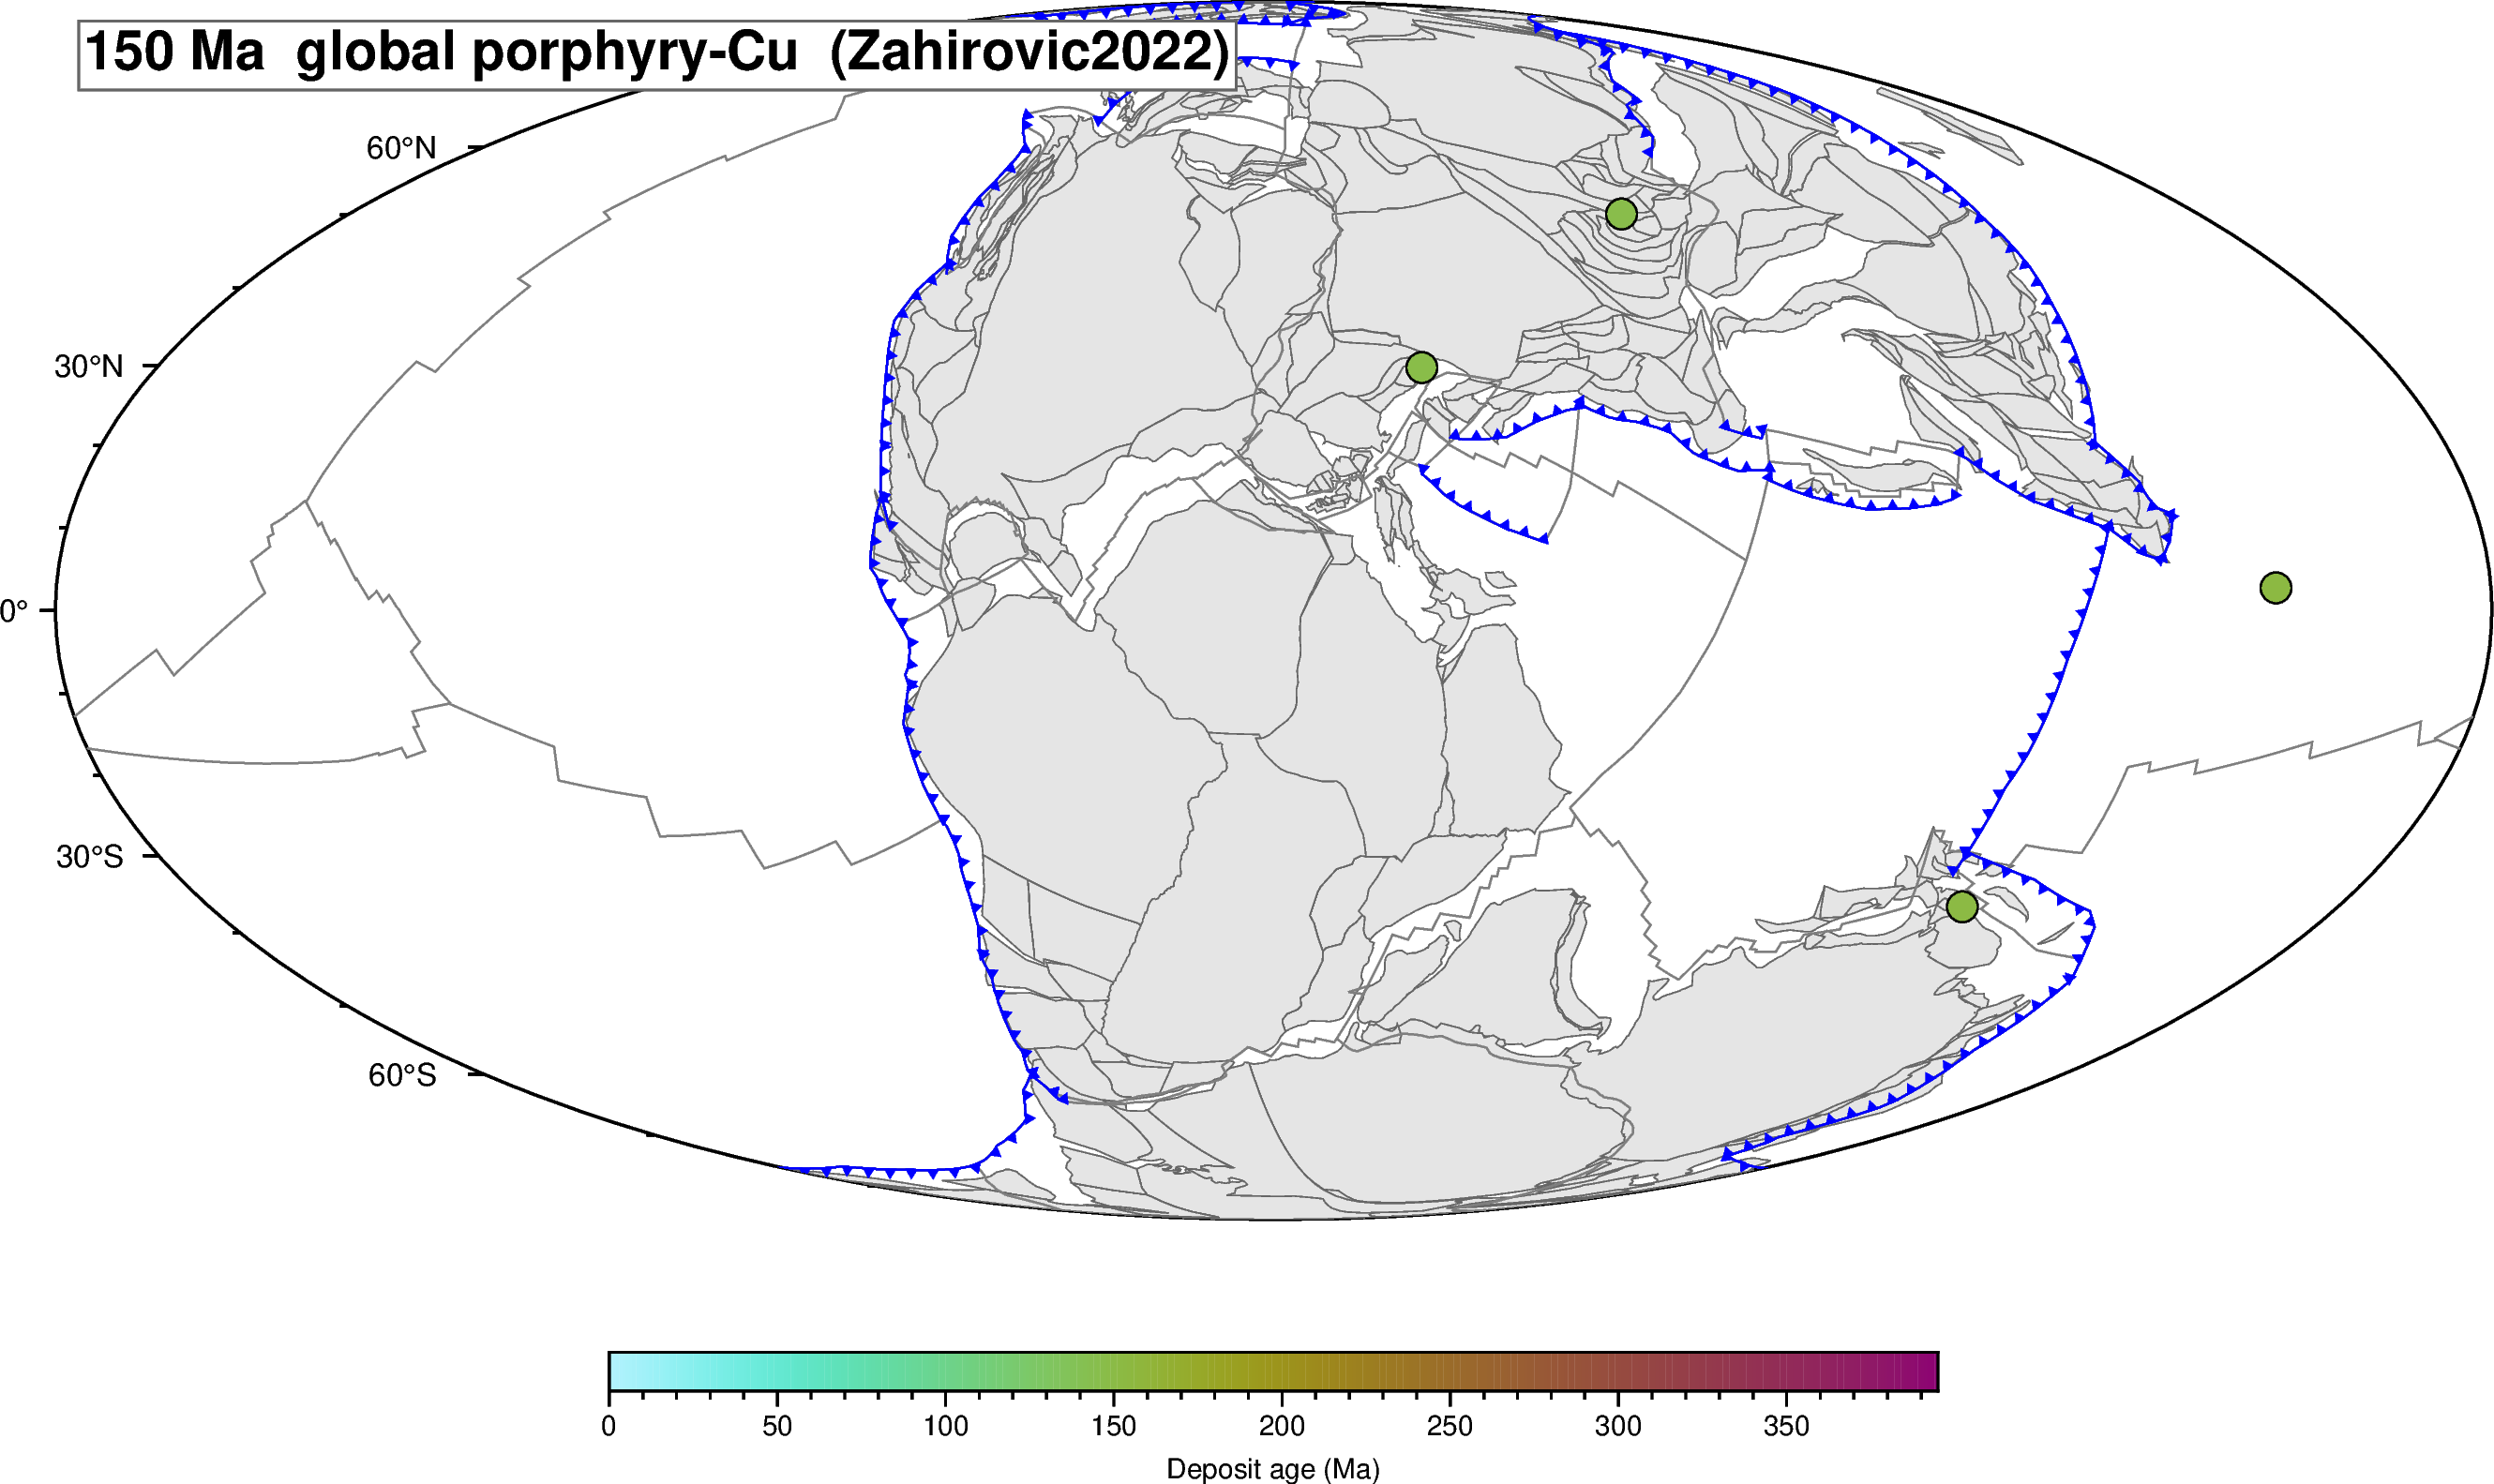

In [13]:
# Cell 5 — render
engine = gplately.PygmtPlotEngine()
for t in SNAPSHOT_TIMES:
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=float(t))
    window = dep[(dep.age_ma >= t - 5) & (dep.age_ma <= t + 5)]

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/22c", frame=["af"])
    engine.plot_geo_data_frame(fig, gplot.get_continents(),
                               fill="gray90", pen="0.3p,gray40")
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.5p,gray50")
    (_tl, _tr) = gplot.get_subduction_direction()
    engine.plot_subduction_zones(fig, _tl, _tr, color="blue")

    if len(window) > 0:
        pygmt.makecpt(cmap="hawaii",
                      series=[dep.age_ma.min(), dep.age_ma.max(), 1], reverse=True)
        fig.plot(x=window["paleo_lon"], y=window["paleo_lat"],
                 style="c0.28c", fill=window["age_ma"], cmap=True,
                 pen="0.5p,black")
        fig.colorbar(frame="af+lDeposit age (Ma)",
                     position="JBC+w12c/0.35c+h+o0/1.2c")

    fig.text(text=f"{t:.0f} Ma  global porphyry-Cu  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)
    display(HTML('<div style="height:1cm"></div>'))


## 5. Distance + convergence-rate envelope

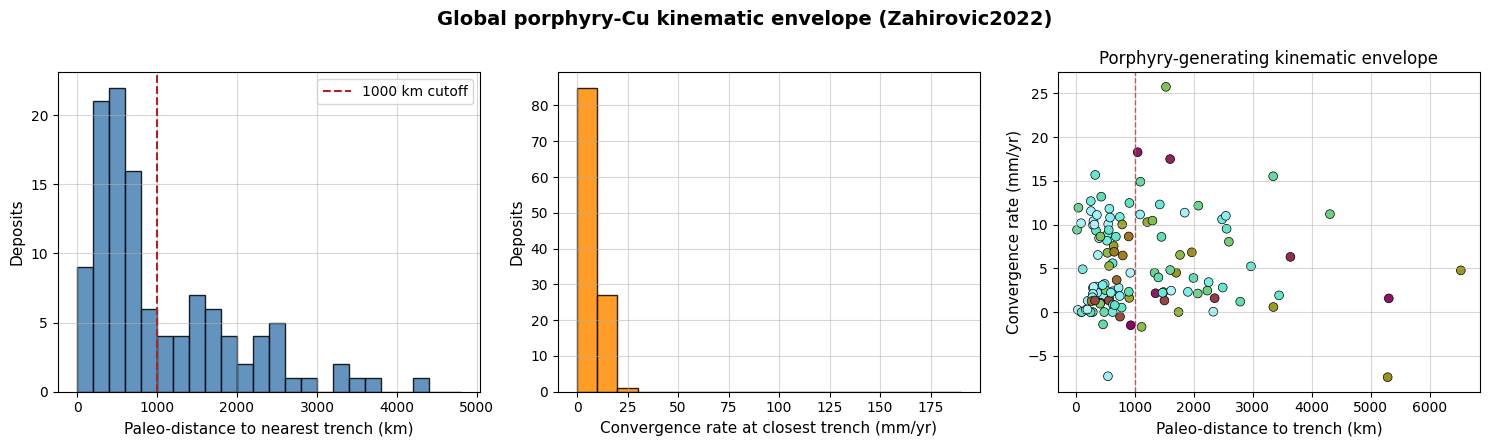

In [14]:
# Cell 6 — kinematic envelope: histogram + bivariate scatter
valid = dep.dropna(subset=["trench_dist_km","conv_rate_mmyr"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(valid.trench_dist_km, bins=np.arange(0, 5000, 200),
             color="steelblue", edgecolor="black", alpha=0.85)
axes[0].axvline(NEAR_TRENCH_KM, color="firebrick", lw=1.5, ls="--",
                label=f"{NEAR_TRENCH_KM:.0f} km cutoff")
axes[0].set_xlabel("Paleo-distance to nearest trench (km)", fontsize=11)
axes[0].set_ylabel("Deposits", fontsize=11); axes[0].grid(True, alpha=0.5); axes[0].legend()

axes[1].hist(valid.conv_rate_mmyr, bins=np.arange(0, 200, 10),
             color="darkorange", edgecolor="black", alpha=0.85)
axes[1].set_xlabel("Convergence rate at closest trench (mm/yr)", fontsize=11)
axes[1].set_ylabel("Deposits", fontsize=11); axes[1].grid(True, alpha=0.5)

axes[2].scatter(valid.trench_dist_km, valid.conv_rate_mmyr,
                c=valid.age_ma, cmap=AGE_CMAP_MPL, s=40,
                edgecolor="black", linewidth=0.5)
axes[2].axvline(NEAR_TRENCH_KM, color="firebrick", lw=1.0, ls="--", alpha=0.7)
axes[2].set_xlabel("Paleo-distance to trench (km)", fontsize=11)
axes[2].set_ylabel("Convergence rate (mm/yr)", fontsize=11)
axes[2].set_title("Porphyry-generating kinematic envelope", fontsize=12)
axes[2].grid(True, alpha=0.5)

plt.suptitle(f"Global porphyry-Cu kinematic envelope ({MODEL_NAME})", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## Extend this

- **ML prospectivity.** The feature stack computed here — distance + convergence rate + age — is the input to the Butterworth et al. (2021) random-forest classifier. Add slab obliquity, trench velocity, and overriding-plate identity from `tessellate_subduction_zones` columns 3–5, 7, and 9 for the full feature set.
- **Commodity filter.** Restrict to `commodity == "Cu-Au"` and re-run. The kinematic envelope shifts — Cu-Au tends to higher-convergence-rate windows than Cu-only.
- **Cross-reference T44 and T40.** T44 is a regional SW-Pacific zoom on this same workflow; T40 is the Cordilleran zoom. T45 generalises both.

## References

- Butterworth, N., Steinberg, D., Müller, R.D., Williams, S., Merdith, A.S. & Hardy, S. (2021). Tectonic environments of South American porphyry copper magmatism through time revealed by spatiotemporal data mining. *Tectonics* 40, e2020TC006273. https://doi.org/10.1029/2020TC006273
- Sillitoe, R.H. (2010). Porphyry copper systems. *Economic Geology* 105(1), 3–41. https://doi.org/10.2113/gsecongeo.105.1.3
- Mutschler, F.E., Ludington, S. & Bookstrom, A.A. (1999). Giant porphyry-related metal camps of the world — a database. *USGS Open-File Report* 99-556.
- Singer, D.A., Berger, V.I. & Moring, B.C. (2008). Porphyry copper deposits of the world: Database and grade and tonnage models. *USGS Open-File Report* 2008-1155.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090